# Day 7 — HuggingFace Transformers & NLP Pipeline
Using pretrained BERT model to classify student feedback from university ML course.
No training required — BERT is already trained on billions of sentences.

In [3]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

In [29]:
import transformers
print("Transformers version:", transformers.__version__)
print("HuggingFace ready ✓")

Transformers version: 5.8.1
HuggingFace ready ✓


In [30]:
from transformers import pipeline
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import pandas as pd 
import matplotlib.pyplot as plt
import os
print("All imports done")

All imports done


## HuggingFace Pipeline — Simplest Way to Use AI
One line loads a pretrained model. One line runs inference. No training needed.

In [14]:
# Load sentiment analysis pipeline — downloads model automatically
# First run takes 1-2 minutes to download, then cached locally
sentiment_pipeline= pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [16]:
# Test on 5 general sentences first
test_sentences = [
    "I love this product, it works perfectly!",
    "This is the worst experience I have ever had.",
    "The service was okay, nothing special.",
    "Absolutely fantastic, highly recommended!",
    "I am very disappointed with the results."
]
results=sentiment_pipeline(test_sentences)
for sentence, result in zip(test_sentences, results):
    emoji = "✅" if result['label'] == 'POSITIVE' else "❌"
    print(f"{emoji} {result['label']:8} ({result['score']:.4f}) | {sentence[:55]}")

✅ POSITIVE (0.9999) | I love this product, it works perfectly!
❌ NEGATIVE (0.9998) | This is the worst experience I have ever had.
❌ NEGATIVE (0.9862) | The service was okay, nothing special.
✅ POSITIVE (0.9999) | Absolutely fantastic, highly recommended!
❌ NEGATIVE (0.9998) | I am very disappointed with the results.


## Under the Hood — Tokenizer & Model
The pipeline hides the details. Here we open it up — tokenize text manually then run the model to understand how BERT works.

In [20]:
model_name="distilbert-base-uncased-finetuned-sst-2-english"
Tokenizer=AutoTokenizer.from_pretrained(model_name)
bert_model=AutoModelForSequenceClassification.from_pretrained(model_name)
bert_model.eval()
print("Tokenizer loaded ✓")
print("Model loaded ✓")
print(f"Model labels: {bert_model.config.id2label}")


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Tokenizer loaded ✓
Model loaded ✓
Model labels: {0: 'NEGATIVE', 1: 'POSITIVE'}


In [28]:
sample="The machine learning lecture was very helpful."
tokens=Tokenizer(sample, return_tensors="pt", padding=True, truncation=True)
print("orginal Senetence", sample)
print("Tokens", tokens['input_ids'].shape[1])
print("Attention mask:", tokens['attention_mask'])
print("Token count:", tokens['input_ids'].shape[1])
# Decode tokens back to words
decoded = Tokenizer.convert_ids_to_tokens(tokens['input_ids'][0])
print("tokens:", decoded)

orginal Senetence The machine learning lecture was very helpful.
Tokens 10
Attention mask: tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
Token count: 10
tokens: ['[CLS]', 'the', 'machine', 'learning', 'lecture', 'was', 'very', 'helpful', '.', '[SEP]']


In [31]:
# Run model inference manually
with torch.no_grad():
    outputs = bert_model(**tokens)
    logits  = outputs.logits
    probs   = torch.softmax(logits, dim=-1)
    pred_id = torch.argmax(probs).item()
    label   = bert_model.config.id2label[pred_id]
    score   = probs[0][pred_id].item()

print(f"Logits: {logits}")
print(f"Probabilities: {probs}")
print(f"Prediction: {label} ({score:.4f})")

Logits: tensor([[-2.9660,  3.0618]])
Probabilities: tensor([[0.0024, 0.9976]])
Prediction: POSITIVE (0.9976)


## Applied NLP — University Student Feedback Analysis
Classifying real student feedback from ML/AI university courses using DistilBERT.
Domain: Education · Use case: Automated feedback monitoring for educators.

In [32]:
# 20 student feedback sentences from ML/AI university course
feedbacks = [
    # Positive
    "The lecture on neural networks was explained very clearly.",
    "I finally understood backpropagation after this class.",
    "The professor made machine learning concepts easy to grasp.",
    "Excellent teaching style, very engaging and interactive.",
    "The examples used in class were very practical and helpful.",
    "I really enjoyed the hands-on coding sessions.",
    "The course material was well organized and easy to follow.",
    "Best ML course I have taken, highly recommended.",
    "The teacher is very patient and answers all questions.",
    "I feel confident about applying ML after this course.",
    # Negative
    "The lectures move too fast, hard to keep up with the pace.",
    "I struggled to understand the math behind the algorithms.",
    "More practical examples would have been helpful.",
    "The assignments were too difficult without enough guidance.",
    "I wish there were more office hours for extra help.",
    "Some topics felt rushed and needed more explanation.",
    "The course content was too theoretical and less practical.",
    "I had difficulty understanding the Python coding parts.",
    # Neutral
    "The course covered many topics but felt a bit overwhelming.",
    "It was an average experience, neither too hard nor too easy."
]

print(f"Total feedback sentences: {len(feedbacks)}")
print("Sample:", feedbacks[0])


Total feedback sentences: 20
Sample: The lecture on neural networks was explained very clearly.


In [33]:
# Run sentiment pipeline on all 20 sentences
results = sentiment_pipeline(feedbacks)

# Build results dataframe
df_results = pd.DataFrame({
    'Feedback'  : feedbacks,
    'Sentiment' : [r['label'] for r in results],
    'Confidence': [round(r['score'], 4) for r in results]
})

print("=== Student Feedback Analysis Results ===")
print(df_results.to_string(index=False))
print(f"\nPositive: {(df_results['Sentiment']=='POSITIVE').sum()}")
print(f"Negative: {(df_results['Sentiment']=='NEGATIVE').sum()}")

=== Student Feedback Analysis Results ===
                                                    Feedback Sentiment  Confidence
  The lecture on neural networks was explained very clearly.  POSITIVE      0.9970
      I finally understood backpropagation after this class.  POSITIVE      0.6426
 The professor made machine learning concepts easy to grasp.  POSITIVE      0.9975
    Excellent teaching style, very engaging and interactive.  POSITIVE      0.9999
 The examples used in class were very practical and helpful.  POSITIVE      0.9996
              I really enjoyed the hands-on coding sessions.  POSITIVE      0.9998
  The course material was well organized and easy to follow.  POSITIVE      0.9998
            Best ML course I have taken, highly recommended.  POSITIVE      0.9995
      The teacher is very patient and answers all questions.  POSITIVE      0.9995
       I feel confident about applying ML after this course.  POSITIVE      0.9993
  The lectures move too fast, hard to keep up

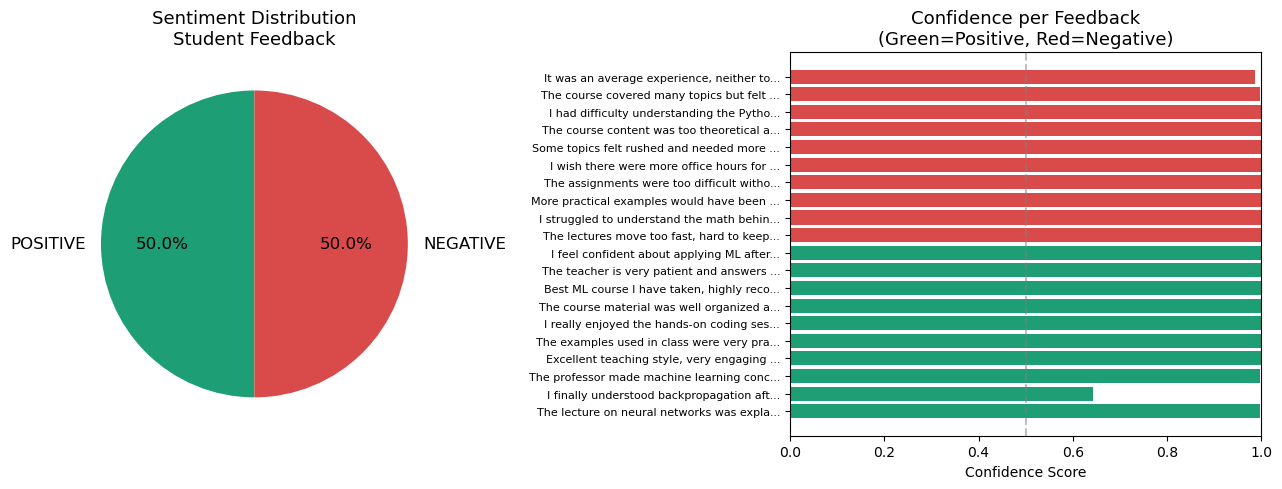

Plot saved ✓


In [34]:
os.makedirs('plots', exist_ok=True)
os.makedirs('data',  exist_ok=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1 — Sentiment distribution pie chart
counts = df_results['Sentiment'].value_counts()
colors = ['#1D9E75', '#D94B4B']
ax1.pie(counts.values, labels=counts.index,
        autopct='%1.1f%%', colors=colors,
        startangle=90, textprops={'fontsize': 12})
ax1.set_title('Sentiment Distribution\nStudent Feedback', fontsize=13)

# Plot 2 — Confidence scores bar chart
colors_bar = ['#1D9E75' if s == 'POSITIVE'
              else '#D94B4B'
              for s in df_results['Sentiment']]
ax2.barh(range(len(feedbacks)),
         df_results['Confidence'], color=colors_bar)
ax2.set_yticks(range(len(feedbacks)))
ax2.set_yticklabels([f[:40]+'...' if len(f)>40
                     else f for f in feedbacks],
                    fontsize=8)
ax2.set_xlabel('Confidence Score')
ax2.set_title('Confidence per Feedback\n(Green=Positive, Red=Negative)',
              fontsize=13)
ax2.set_xlim(0, 1)
ax2.axvline(0.5, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('plots/day7_feedback_sentiment.png', dpi=150)
plt.show()
print("Plot saved ✓")

In [35]:
# Save results as CSV
df_results.to_csv('data/student_feedback_results.csv', index=False)
print("Results saved to CSV ✓")

# Print summary statistics
print("\n=== Summary ===")
print(f"Total sentences analyzed : {len(df_results)}")
print(f"Positive feedback        : {(df_results['Sentiment']=='POSITIVE').sum()}")
print(f"Negative feedback        : {(df_results['Sentiment']=='NEGATIVE').sum()}")
print(f"Avg confidence           : {df_results['Confidence'].mean():.4f}")
print(f"Most confident prediction: {df_results['Confidence'].max():.4f}")
print(f"Least confident          : {df_results['Confidence'].min():.4f}")

Results saved to CSV ✓

=== Summary ===
Total sentences analyzed : 20
Positive feedback        : 10
Negative feedback        : 10
Avg confidence           : 0.9807
Most confident prediction: 0.9999
Least confident          : 0.6426
